# Redes Neurais Recorrentes: RNN e LSTM para Dados Sequenciais
### Disciplina: Inteligência Artificial — Graduação em Ciência da Computação

---

## Objetivos da Aula

Ao final desta aula, você será capaz de:
- Entender por que dados **sequenciais** (séries temporais, texto, áudio) exigem uma arquitetura diferente de MLPs e CNNs
- Compreender o funcionamento de uma **Rede Neural Recorrente (RNN)** e sua fórmula de recorrência
- Explicar o **problema do gradiente desvanecente** e por que ele limita RNNs simples
- Entender a arquitetura **LSTM (Long Short-Term Memory)** e o papel de cada porta (gate)
- Construir, treinar e avaliar modelos RNN e LSTM com Keras para previsão de séries temporais
- Comparar RNN, LSTM e GRU em termos de desempenho e custo computacional

## Conexão com as aulas anteriores

Na Aula 1 usamos MLP/CNN para classificar imagens — entradas de **tamanho fixo** sem noção de ordem temporal. Nesta aula trabalhamos com dados onde **a ordem é a informação**: o valor de hoje depende do histórico recente. Reaproveitaremos conceitos das aulas anteriores: normalização (Aula 3), divisão treino/teste, curvas de loss e overfitting (Aula 2 e 3).

## 1. Configuração do Ambiente

In [ ]:
!pip install yfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


## 2. Dados Sequenciais: Por que MLP e CNN Não Bastam

| Característica | MLP / CNN | Dados Sequenciais |
|---|---|---|
| Tamanho da entrada | Fixo (ex: 28x28 pixels) | Variável (frases, séries com tamanhos diferentes) |
| Ordem dos dados | Irrelevante (pixels podem ser reorganizados com a mesma arquitetura) | **Fundamental** — trocar a ordem muda o significado |
| Memória de eventos passados | Nenhuma | Necessária — o presente depende do passado |
| Exemplos | Imagem de um dígito, foto de um gato | Preço de uma ação no tempo, frase, áudio, sinal de ECG |

**A ideia central de uma RNN**: em vez de processar toda a sequência de uma vez, a rede processa **um elemento por vez**, mantendo um **estado oculto (hidden state)** que funciona como uma "memória" do que já foi visto.

## 3. Carregando o Dataset — Série Temporal de Preços de Ações

Vamos usar o histórico de preços de fechamento de uma ação (Apple - AAPL) como exemplo de série temporal real. O objetivo: **prever o preço de fechamento do próximo dia a partir dos últimos 30 dias**.

Total de pontos: 2515
Ticker         AAPL
count   2515.000000
mean      93.623190
std       65.259577
min       20.565870
25%       35.138063
50%       64.254372
75%      149.941132
max      257.375610


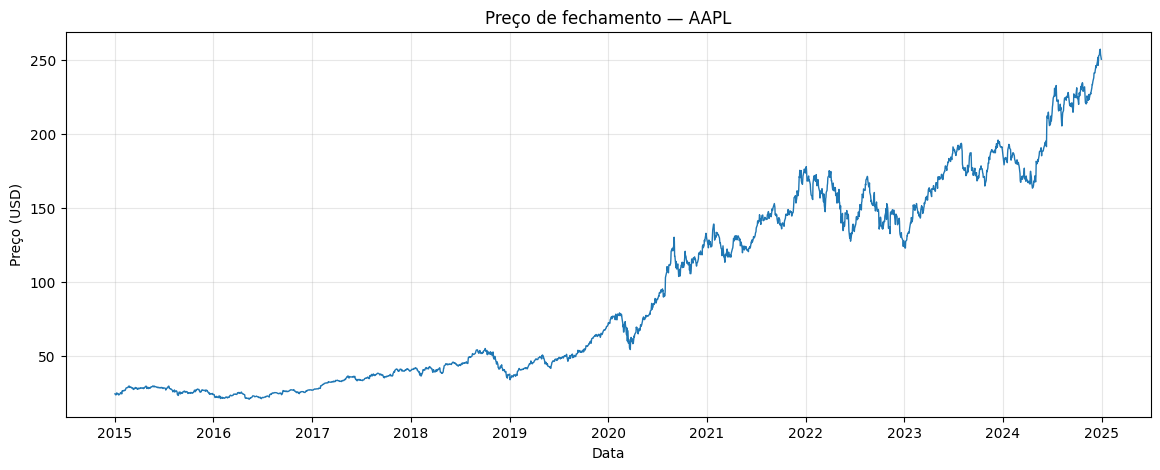

In [ ]:
import yfinance as yf

ticker = 'AAPL'
dados = yf.download(ticker, start='2015-01-01', end='2024-12-31', progress=False)
serie = dados['Close'].dropna()

print(f'Total de pontos: {len(serie)}')
print(serie.describe())

plt.figure(figsize=(14, 5))
plt.plot(serie.index, serie.values, linewidth=1)
plt.title(f'Preço de fechamento — {ticker}')
plt.xlabel('Data')
plt.ylabel('Preço (USD)')
plt.grid(alpha=0.3)
plt.show()

## 4. Pré-processamento: Normalização e Janelas Deslizantes

Duas etapas essenciais antes de treinar uma RNN/LSTM:

1. **Normalização** (`MinMaxScaler`): redes recorrentes usam funções como `tanh`, que saturam para valores grandes. Preços em centenas de dólares precisam ser escalados para o intervalo [0, 1].
2. **Janela deslizante (sliding window)**: transformamos a série em pares `(X, y)`, onde `X` são os últimos *N* valores e `y` é o valor seguinte. Essa é a forma como dados sequenciais são apresentados a redes recorrentes.

> **Atenção**: ao dividir em treino/teste, **não embaralhamos os dados** — a ordem temporal precisa ser preservada (treino = passado, teste = futuro).

In [ ]:
# Normaliza os preços para o intervalo [0, 1]
scaler = MinMaxScaler()
valores = scaler.fit_transform(serie.values.reshape(-1, 1))

JANELA = 30  # usa os últimos 30 dias para prever o próximo

def criar_janelas(dados, janela):
    X, y = [], []
    for i in range(len(dados) - janela):
        X.append(dados[i:i + janela, 0])
        y.append(dados[i + janela, 0])
    return np.array(X), np.array(y)

X, y = criar_janelas(valores, JANELA)

# Split temporal: 80% mais antigo para treino, 20% mais recente para teste
split = int(len(X) * 0.8)
X_tr, X_ts = X[:split], X[split:]
y_tr, y_ts = y[:split], y[split:]

# Reshape para (amostras, passos_de_tempo, features) - formato exigido por RNN/LSTM
X_tr = X_tr.reshape(-1, JANELA, 1)
X_ts = X_ts.reshape(-1, JANELA, 1)

print(f'Treino: {X_tr.shape}, Teste: {X_ts.shape}')
print(f'Exemplo - janela X[0] tem {X_tr[0].shape[0]} passos de tempo, y[0] = {y_tr[0]:.4f}')

Treino: (1988, 30, 1), Teste: (497, 30, 1)
Exemplo - janela X[0] tem 30 passos de tempo, y[0] = 0.0331


## 5. Redes Neurais Recorrentes (RNN)

Uma RNN processa a sequência passo a passo, atualizando um **estado oculto** $h_t$ a cada novo elemento $x_t$:

$$h_t = \tanh(W_x \, x_t + W_h \, h_{t-1} + b)$$

- $x_t$: entrada no instante $t$ (ex: preço normalizado do dia $t$)
- $h_{t-1}$: estado oculto do passo anterior ("memória")
- $W_x$, $W_h$, $b$: pesos **compartilhados** entre todos os passos de tempo
- $h_t$: novo estado oculto, passado para o próximo passo e/ou usado para gerar a saída

Os mesmos pesos são reutilizados a cada passo — é isso que permite à RNN processar sequências de qualquer tamanho com um número fixo de parâmetros.

Vamos construir uma RNN simples (`SimpleRNN`) para prever o próximo valor da série.

In [ ]:
modelo_rnn = keras.Sequential([
    layers.SimpleRNN(32, activation='tanh', input_shape=(JANELA, 1)),
    layers.Dense(1)
])
modelo_rnn.compile(optimizer='adam', loss='mse')
modelo_rnn.summary()

hist_rnn = modelo_rnn.fit(
    X_tr, y_tr,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

print(f"Loss final (treino):    {hist_rnn.history['loss'][-1]:.5f}")
print(f"Loss final (validação): {hist_rnn.history['val_loss'][-1]:.5f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

Loss final (treino):    0.00011
Loss final (validação): 0.00044


## 6. O Problema do Gradiente Desvanecente

Para treinar uma RNN, usamos **Backpropagation Through Time (BPTT)**: o erro é propagado de volta através de cada passo de tempo. Como os mesmos pesos $W_h$ são aplicados repetidamente, o gradiente envolve um produto de muitos termos:

$$\frac{\partial L}{\partial h_0} \propto \prod_{t=1}^{T} \frac{\partial h_t}{\partial h_{t-1}}$$

- Se cada termo for **menor que 1**, o produto encolhe exponencialmente → **gradiente desvanece (vanishing gradient)** → a rede "esquece" dependências de longo prazo
- Se cada termo for **maior que 1**, o produto explode → **gradiente explode (exploding gradient)** → pesos viram `NaN`

**Consequência prática**: uma `SimpleRNN` consegue aprender dependências de curto prazo (poucos passos), mas tem dificuldade em relacionar eventos distantes na sequência (ex: lembrar uma tendência de 60 dias atrás). Essa limitação motivou a criação da **LSTM**.

## 7. LSTM — Long Short-Term Memory

A LSTM resolve o problema do gradiente desvanecente introduzindo um **estado de célula** ($C_t$) controlado por três **portas (gates)**, cada uma uma rede neural com ativação sigmoide (saída entre 0 e 1, funcionando como uma "válvula"):

| Porta | Pergunta que responde |
|---|---|
| **Forget gate** ($f_t$) | O que devo esquecer do estado anterior? |
| **Input gate** ($i_t$) | Quanto da nova informação devo guardar? |
| **Output gate** ($o_t$) | Quanto do estado de célula devo expor como saída? |

As fórmulas de cada porta seguem o mesmo padrão — uma combinação linear do estado oculto anterior e da entrada atual, passada por uma sigmoide:

$$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$$

$$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$$

$$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$$

O estado de célula é atualizado como:

$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

Como a atualização de $C_t$ envolve uma **soma** (e não apenas multiplicações sucessivas), o gradiente pode fluir por muitos passos de tempo sem desaparecer — é o chamado **"caminho de gradiente ininterrupto"** da LSTM.

Vamos treinar uma LSTM com a mesma arquitetura geral da RNN anterior, para comparação direta.

In [ ]:
modelo_lstm = keras.Sequential([
    layers.LSTM(32, activation='tanh', input_shape=(JANELA, 1)),
    layers.Dense(1)
])
modelo_lstm.compile(optimizer='adam', loss='mse')
modelo_lstm.summary()

hist_lstm = modelo_lstm.fit(
    X_tr, y_tr,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

print(f"Loss final (treino):    {hist_lstm.history['loss'][-1]:.5f}")
print(f"Loss final (validação): {hist_lstm.history['val_loss'][-1]:.5f}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

Loss final (treino):    0.00013
Loss final (validação): 0.00062


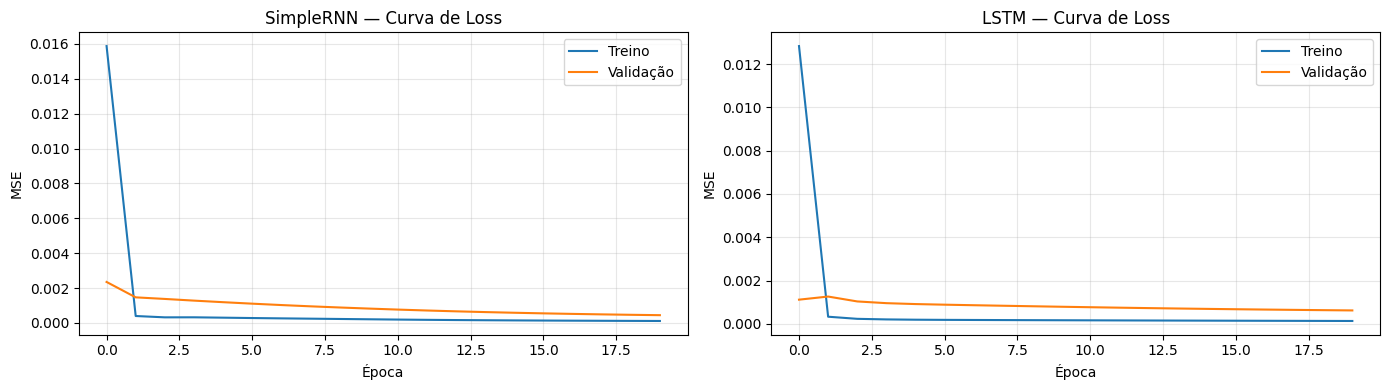

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(hist_rnn.history['loss'], label='Treino')
axes[0].plot(hist_rnn.history['val_loss'], label='Validação')
axes[0].set_title('SimpleRNN — Curva de Loss')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('MSE')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist_lstm.history['loss'], label='Treino')
axes[1].plot(hist_lstm.history['val_loss'], label='Validação')
axes[1].set_title('LSTM — Curva de Loss')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('MSE')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Avaliando as Previsões no Conjunto de Teste

Agora comparamos as previsões de cada modelo com os valores reais (desfazendo a normalização com `scaler.inverse_transform`), usando **MAE** (erro absoluto médio) e **RMSE** (raiz do erro quadrático médio) — ambos na escala original em dólares.

Modelo        MAE (US$)   RMSE (US$)
SimpleRNN          7.09         9.23
LSTM               7.25         8.82


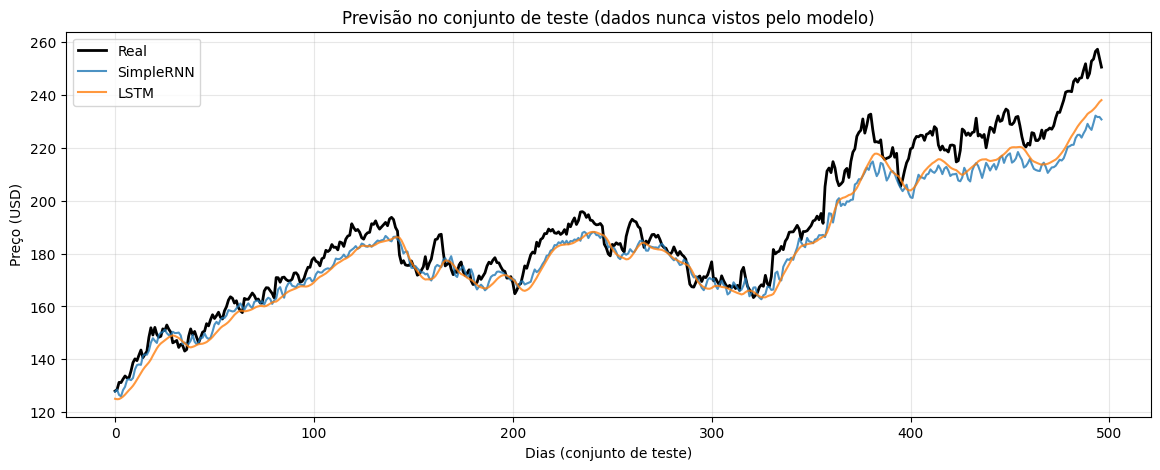

In [ ]:
pred_rnn = scaler.inverse_transform(modelo_rnn.predict(X_ts, verbose=0))
pred_lstm = scaler.inverse_transform(modelo_lstm.predict(X_ts, verbose=0))
real = scaler.inverse_transform(y_ts.reshape(-1, 1))

print(f"{'Modelo':<12} {'MAE (US$)':>10} {'RMSE (US$)':>12}")
for nome, pred in [('SimpleRNN', pred_rnn), ('LSTM', pred_lstm)]:
    mae = mean_absolute_error(real, pred)
    rmse = np.sqrt(mean_squared_error(real, pred))
    print(f'{nome:<12} {mae:>10.2f} {rmse:>12.2f}')

plt.figure(figsize=(14, 5))
plt.plot(real, label='Real', linewidth=2, color='black')
plt.plot(pred_rnn, label='SimpleRNN', alpha=0.8)
plt.plot(pred_lstm, label='LSTM', alpha=0.8)
plt.title('Previsão no conjunto de teste (dados nunca vistos pelo modelo)')
plt.xlabel('Dias (conjunto de teste)')
plt.ylabel('Preço (USD)')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 9. GRU — Uma Alternativa mais Leve à LSTM

A **GRU (Gated Recurrent Unit)** simplifica a LSTM combinando os gates de *forget* e *input* em um único **update gate**, e elimina o estado de célula separado. Resultado: ~25% menos parâmetros que a LSTM, treinamento mais rápido, com desempenho frequentemente comparável.

| | RNN Simples | GRU | LSTM |
|---|---|---|---|
| Nº de gates | 0 | 2 | 3 |
| Memória de longo prazo | Fraca | Boa | Melhor |
| Nº de parâmetros (por unidade) | Menor | Médio | Maior |
| Velocidade de treino | Mais rápida | Rápida | Mais lenta |
| Quando usar | Sequências curtas, baseline | Bom custo/benefício | Sequências longas, dependências complexas |

No Keras, basta trocar `layers.LSTM(...)` por `layers.GRU(...)` — a interface é idêntica.

---
## 10. Exercícios

### Exercício 1 — Treine uma GRU e compare
Construa um modelo `keras.Sequential` usando `layers.GRU(32, activation='tanh', input_shape=(JANELA, 1))` seguido de `layers.Dense(1)`. Treine com os mesmos dados (`X_tr`, `y_tr`) e compare o MAE/RMSE com SimpleRNN e LSTM.

In [ ]:
modelo_gru = keras.Sequential([
    layers.GRU(32, activation='tanh', input_shape=(JANELA, 1)),
    layers.Dense(1)
])
modelo_gru.compile(optimizer='adam', loss='mse')

hist_gru = modelo_gru.fit(
    X_tr, y_tr,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

pred_gru = scaler.inverse_transform(modelo_gru.predict(X_ts, verbose=0))

print(f"{'Modelo':<12} {'MAE (US$)':>10} {'RMSE (US$)':>12}")
for nome, pred in [('SimpleRNN', pred_rnn), ('LSTM', pred_lstm), ('GRU', pred_gru)]:
    mae = mean_absolute_error(real, pred)
    rmse = np.sqrt(mean_squared_error(real, pred))
    print(f'{nome:<12} {mae:>10.2f} {rmse:>12.2f}')

### Exercício 2 — Efeito do Tamanho da Janela
Repita o pré-processamento (seção 4) com `JANELA = 10` e `JANELA = 60`. Treine a LSTM novamente para cada caso e compare o RMSE. Janelas maiores sempre melhoram o resultado? Por quê?

In [ ]:
def avaliar_janela(janela):
    X, y = criar_janelas(valores, janela)
    split = int(len(X) * 0.8)
    X_tr = X[:split].reshape(-1, janela, 1)
    X_ts = X[split:].reshape(-1, janela, 1)
    y_tr, y_ts = y[:split], y[split:]

    modelo = keras.Sequential([
        layers.LSTM(32, activation='tanh', input_shape=(janela, 1)),
        layers.Dense(1)
    ])
    modelo.compile(optimizer='adam', loss='mse')
    modelo.fit(X_tr, y_tr, epochs=20, batch_size=32, validation_split=0.1, verbose=0)

    pred = scaler.inverse_transform(modelo.predict(X_ts, verbose=0))
    real_j = scaler.inverse_transform(y_ts.reshape(-1, 1))
    return np.sqrt(mean_squared_error(real_j, pred))

for j in [10, 30, 60]:
    rmse = avaliar_janela(j)
    print(f'JANELA={j:<3} RMSE = {rmse:.2f}')

print()
print('Janelas maiores nao melhoram sempre: dao mais contexto, mas reduzem o numero')
print('de amostras de treino e tornam o aprendizado mais dificil (gradiente precisa')
print('percorrer mais passos). O ideal e o tamanho que equilibra contexto e dados disponiveis.')

### Exercício 3 — LSTM Empilhada (Stacked LSTM)
Crie um modelo com duas camadas LSTM empilhadas. **Dica**: a primeira camada precisa de `return_sequences=True` para que a segunda receba uma sequência (e não um único vetor):

```python
keras.Sequential([
    layers.LSTM(32, activation='tanh', return_sequences=True, input_shape=(JANELA, 1)),
    layers.LSTM(16, activation='tanh'),
    layers.Dense(1)
])
```

Treine e avalie. O desempenho melhorou em relação à LSTM de uma camada? Houve overfitting (loss de treino muito menor que validação)?

In [ ]:
modelo_stacked = keras.Sequential([
    layers.LSTM(32, activation='tanh', return_sequences=True, input_shape=(JANELA, 1)),
    layers.LSTM(16, activation='tanh'),
    layers.Dense(1)
])
modelo_stacked.compile(optimizer='adam', loss='mse')

hist_stacked = modelo_stacked.fit(
    X_tr, y_tr,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

pred_stacked = scaler.inverse_transform(modelo_stacked.predict(X_ts, verbose=0))
mae = mean_absolute_error(real, pred_stacked)
rmse = np.sqrt(mean_squared_error(real, pred_stacked))

print(f'LSTM empilhada - MAE: {mae:.2f}, RMSE: {rmse:.2f}')
print(f"Loss treino: {hist_stacked.history['loss'][-1]:.5f}, Loss validacao: {hist_stacked.history['val_loss'][-1]:.5f}")
print(f"(LSTM simples) Loss treino: {hist_lstm.history['loss'][-1]:.5f}, Loss validacao: {hist_lstm.history['val_loss'][-1]:.5f}")

### Exercício 4 — Entrada Multivariada
Até agora usamos apenas o preço de fechamento (`Close`). Modifique a função `criar_janelas` para incluir também `Open`, `High`, `Low` e `Volume` como features adicionais (a entrada passa a ter shape `(JANELA, 5)` em vez de `(JANELA, 1)`). Normalize cada coluna separadamente. O modelo melhora ao receber mais informação?

In [ ]:
colunas = ['Open', 'High', 'Low', 'Close', 'Volume']
dados_multi = dados[colunas].dropna().values
IDX_CLOSE = colunas.index('Close')

scaler_multi = MinMaxScaler()
valores_multi = scaler_multi.fit_transform(dados_multi)

def criar_janelas_multi(dados, janela, idx_alvo):
    X, y = [], []
    for i in range(len(dados) - janela):
        X.append(dados[i:i + janela])
        y.append(dados[i + janela, idx_alvo])
    return np.array(X), np.array(y)

X_multi, y_multi = criar_janelas_multi(valores_multi, JANELA, IDX_CLOSE)

split = int(len(X_multi) * 0.8)
X_tr_multi, X_ts_multi = X_multi[:split], X_multi[split:]
y_tr_multi, y_ts_multi = y_multi[:split], y_multi[split:]

modelo_multi = keras.Sequential([
    layers.LSTM(32, activation='tanh', input_shape=(JANELA, len(colunas))),
    layers.Dense(1)
])
modelo_multi.compile(optimizer='adam', loss='mse')
modelo_multi.fit(
    X_tr_multi, y_tr_multi,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

def desfazer_normalizacao(coluna_normalizada, scaler, idx_coluna, n_colunas):
    dummy = np.zeros((len(coluna_normalizada), n_colunas))
    dummy[:, idx_coluna] = coluna_normalizada.flatten()
    return scaler.inverse_transform(dummy)[:, idx_coluna]

pred_multi = desfazer_normalizacao(modelo_multi.predict(X_ts_multi, verbose=0), scaler_multi, IDX_CLOSE, len(colunas))
real_multi = desfazer_normalizacao(y_ts_multi.reshape(-1, 1), scaler_multi, IDX_CLOSE, len(colunas))

mae = mean_absolute_error(real_multi, pred_multi)
rmse = np.sqrt(mean_squared_error(real_multi, pred_multi))
print(f'LSTM multivariada - MAE: {mae:.2f}, RMSE: {rmse:.2f}')
print(f'LSTM univariada (Close apenas) - MAE: {mean_absolute_error(real, pred_lstm):.2f}, RMSE: {np.sqrt(mean_squared_error(real, pred_lstm)):.2f}')

---
## 11. Resumo: Quando Usar Cada Arquitetura?

```
PROBLEMA                                  ->  ARQUITETURA RECOMENDADA
------------------------------------------------------------------------
Entrada de tamanho fixo, sem ordem        ->  MLP
Imagens / padrões espaciais               ->  CNN
Sequência curta, dependências simples     ->  SimpleRNN (raramente usado na prática)
Bom custo/benefício, sequências médias    ->  GRU
Dependências de longo prazo               ->  LSTM (ou LSTM empilhada)
Sequências muito longas / paralelismo     ->  Transformers (próxima fronteira)
```

In [ ]:
print('=== Resumo dos conceitos desta aula ===')
conceitos = [
    '- Dados sequenciais: a ordem das observações carrega informação',
    '- Janela deslizante: transforma uma série temporal em pares (X, y) supervisionados',
    '- RNN: estado oculto h_t atualizado a cada passo, pesos compartilhados no tempo',
    '- BPTT: backpropagation through time -> origem do gradiente desvanecente/explosivo',
    '- LSTM: forget/input/output gates + estado de célula -> memória de longo prazo',
    '- GRU: versão simplificada da LSTM, menos parâmetros, treino mais rápido',
    '- Split temporal: nunca embaralhar dados de série temporal',
]
for c in conceitos:
    print(c)

---
## Referências

1. Hochreiter, S. & Schmidhuber, J. (1997). *Long Short-Term Memory*. Neural Computation, 9(8), 1735-1780.
2. Cho, K. et al. (2014). *Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation* (introdução da GRU).
3. Goodfellow, I., Bengio, Y. & Courville, A. (2016). *Deep Learning*. MIT Press — Capítulo 10 (Sequence Modeling: Recurrent and Recursive Nets).
4. Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow* (3ª ed.). O'Reilly — Capítulo 15 (Processing Sequences Using RNNs and CNNs).
5. Documentação Keras: https://keras.io/api/layers/recurrent_layers/